In [ ]:
# Linear Regression
%pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
# needed for performing stats operations
import numpy as np

# needed to load the dataset
import pandas as pd

# needed to visualize the data (creating charts)
import matplotlib.pyplot as plt
import seaborn as sns
# LinearRegression is the class / algorithm to build the model
from sklearn.linear_model import LinearRegression

In [3]:
# load the csv file and convert it into dataframe
# dataframe is a two dimensional array
#ref data link https://www.kaggle.com/datasets/rohankayan/years-of-experience-and-salary-dataset
df = pd.read_csv("Salary_Data.csv")

In [4]:
# find the columns from the dataset
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [5]:
# get basic information about all the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [6]:
# get the basic stats about the dataset
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [7]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [8]:
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


Text(0.5, 1.0, 'Experience vs Salary')

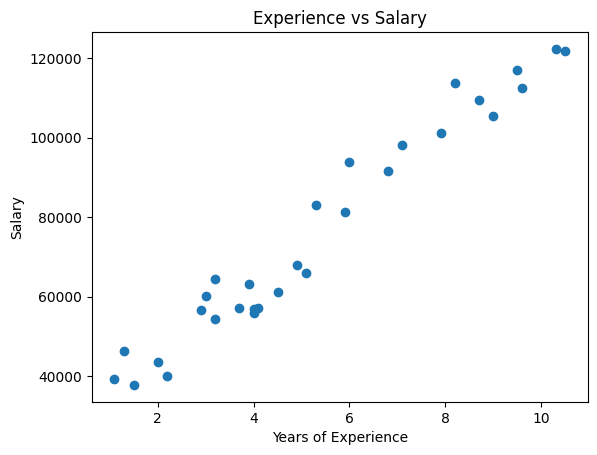

In [9]:
# visualize the data
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')

In [10]:
# covariance tells if relationship is +ve or -ve, but it will not tell is relationship is strong or weak.
df.cov()


# [[cov(x, x)  cov(x, y)]
#  [cov(y, x)  cov(y, y)]]

# cov(x, y) = cov(y, x)
# since the covariance is +ve, there must a +ve relationship between YearsExperience and Salary

,YearsExperience,Salary
YearsExperience,8.053609,7.610630e+04
Salary,76106.303448,7.515510e+08


In [11]:
# find out if the relationship is strong or weak
np.corrcoef(df['YearsExperience'], df['Salary'])

# [[corrcoef(x, x)  corrcoef(x, y)]
#  [corrcoef(y, x)  corrcoef(y, y)]]

# corrcoef(x, x) = corrcoef(y, y) = 1
# corrcoef(x, y) = corrcoef(y, x)

# correlation coefficient
# -1 ---- 0 ---- +1

array([[1.        , 0.97824162],
       [0.97824162, 1.        ]])

In [12]:
# split the data into X and Y

# independent variable (x)
# - it is mandatory to have it in two dimensional array or a dataframe
# - since we are removing the Salary variable, x will be having only one variable named YearsExperience
# - axis = 0 -> row, axis = 1 -> column
x = df.drop('Salary', axis=1)

# dependent variable (y)
# - it is mandatory to have it in one dimensional array or series
y = df['Salary']  

In [13]:
# create a model object
model = LinearRegression()

# fit the data to find the model
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# find the salary of a person having 11 years experience
salaries = model.predict([[11]])
salaries

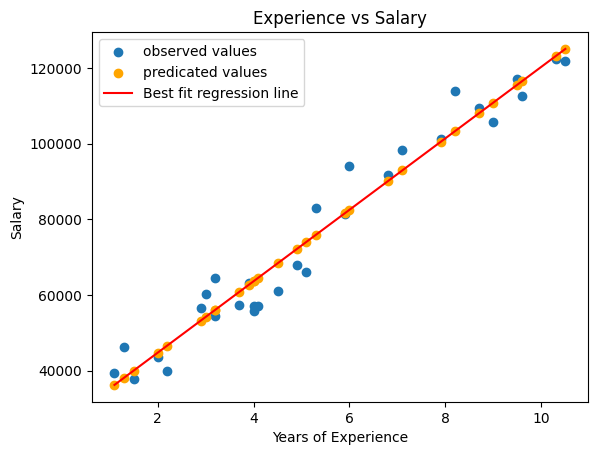

In [15]:
# visualize the data
plt.scatter(df['YearsExperience'], df['Salary'], label="observed values")
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Experience vs Salary')

# draw the best-fit regression line
plt.scatter(df['YearsExperience'], model.predict(x), color="orange", label="predicated values")
plt.plot(df['YearsExperience'], model.predict(x), color="red", label="Best fit regression line")

plt.legend()